# Q1: Renewable forecast errors and next-day prices

**Question.** When realised wind and solar deviate from the day-ahead forecast
(`actual - forecast`, in MW), how does that propagate into subsequent day-ahead
auction prices, and does the impact grow with Germany's renewable build-out?

The price leg is the Belgian day-ahead price (column `id_continuous`; the series
map is in `FINDINGS.md`). A day-ahead price for hour *t* is fixed around 12:45
the day before, so the error realised at hour *t* cannot move it through any
trading channel. What the VAR picks up is propagation into later auctions of a
tightly coupled zone, through weather persistence and shared drivers.

**Method.**
1. ADF stationarity on the level series (first-difference fallback).
2. AIC-based VAR lag selection up to 24 hours.
3. Granger F-tests in both directions.
4. Cholesky-orthogonalised impulse response with residual-bootstrap bands, plus
   the forecast-error variance decomposition.
5. Rolling one-year Granger p-values for temporal stability.
6. Bai-Perron breaks on the daily impact coefficient. The prefix-sum DP makes
   the full sample feasible.

**Data.** DE/LU bidding zone, hourly. Forecasts and generation actuals from
ENTSO-E, zonal prices from SMARD. The cells below read artifacts produced by
`scripts/run_full_analysis.py`; run that first if `results/` is empty.


In [1]:
# Common imports, shared by all three notebooks.
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
FIG = RESULTS / 'figures'
TAB = RESULTS / 'tables'

with open(RESULTS / 'summary.json') as f:
    SUMMARY = json.load(f)

WINDOW = SUMMARY['window']
print(f"Sample window: {WINDOW['start']} → {WINDOW['end']}")


Sample window: 2018-10-01 → 2026-05-04


## 1.  Forecast-error structure over the sample

Annual standard deviations track the growth of the fleet: wind dominates the
variance budget, and solar's contribution rises with PV additions.


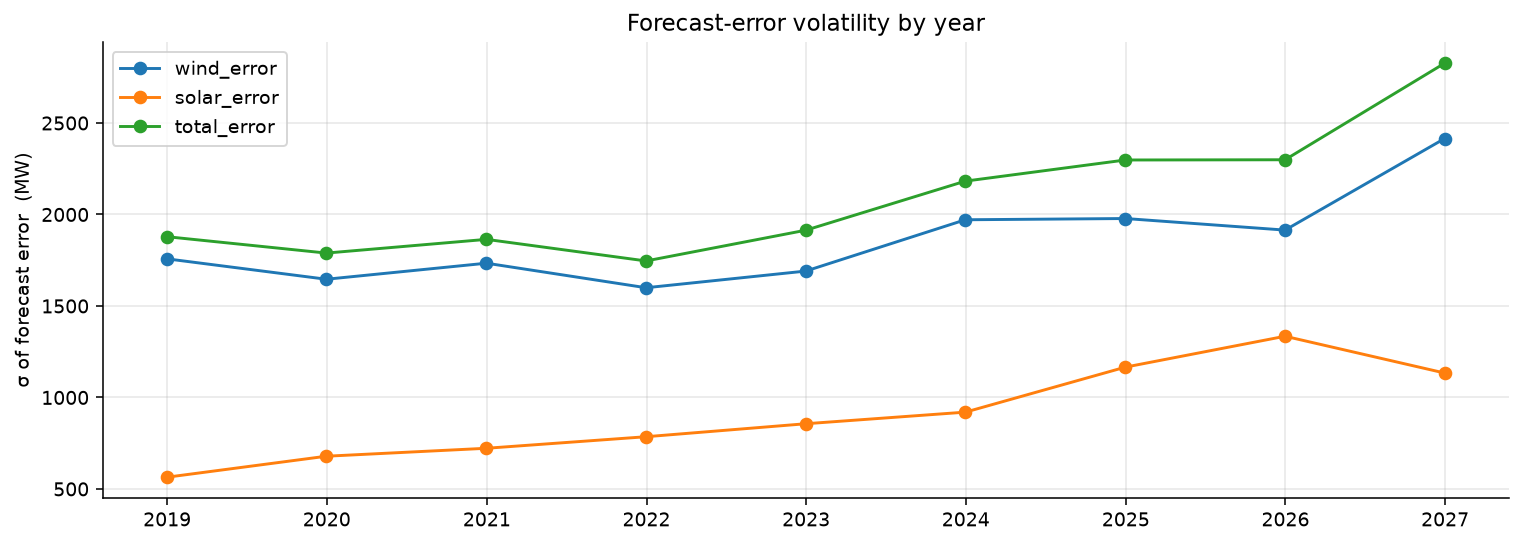

In [2]:
display(Image(str(FIG / 'q1_yearly_error_std.png')))

In [3]:
df = pd.read_csv(TAB / 'q1_yearly_descriptives.csv', index_col=0)
display(df)

,wind_error,wind_error.1,solar_error,solar_error.1,total_error,total_error.1
NaN,std,mean,std,mean,std,mean
year,NaN,NaN,NaN,NaN,NaN,NaN
2018,1757.7593979018043,224.31516968325786,563.903013138138,-101.07295588235293,1878.7327404199148,123.24221380090492
2019,1646.1049474800889,159.66352368721465,678.8063703784173,30.368882420091342,1789.1472744079085,190.03240610730597
2020,1733.7748932052752,75.31301238995144,722.253105273717,8.106606329690347,1864.032692810057,83.41961871964178
2021,1599.6679196204484,64.456774543379,785.3614687988705,-31.0552408675799,1746.0267539119923,33.401533675799094
2022,1690.719509262325,209.0879125761035,856.293103067655,25.22485131278539,1914.016506870591,234.31276388888887
2023,1971.183854154617,93.7866700913242,919.6771108740713,-16.67616723744291,2182.396869464844,77.11050285388129
2024,1977.941874891781,-21.667898831208266,1165.792305836062,-122.439585325592,2297.874842500355,-144.10748415680024
2025,1914.6832089217185,193.8527594894597,1334.5229776608653,13.724475192846263,2299.153391892327,207.5772346823059


Renewable penetration over the sample. The Bai-Perron break dates below get
checked against this trend.


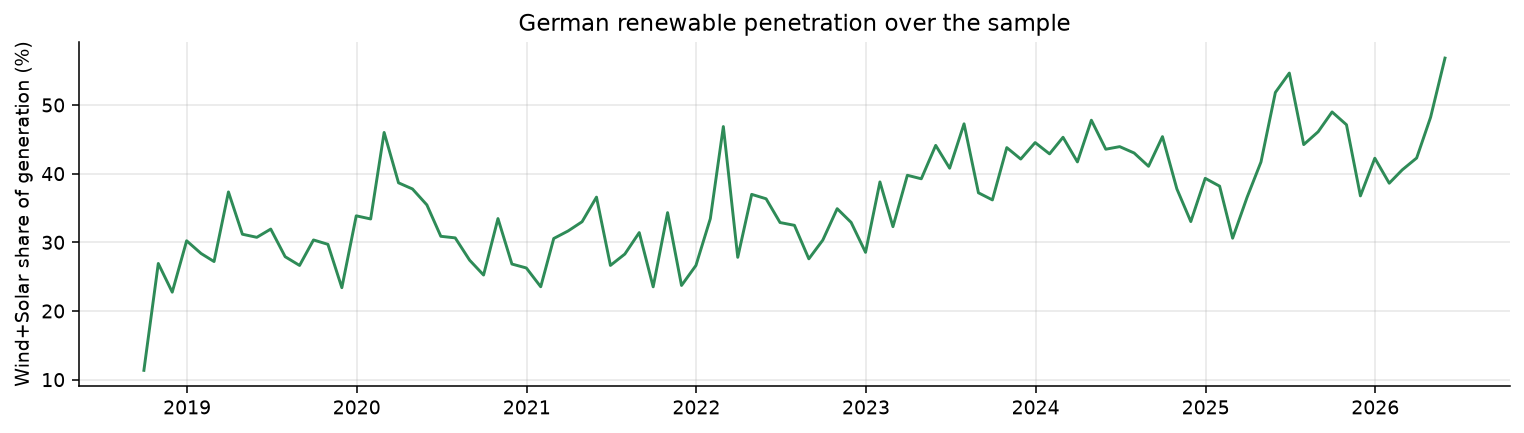

In [4]:
display(Image(str(FIG / 'q1_renewable_share.png')))

## 2.  Granger causality (full sample)

In [5]:
df = pd.read_csv(TAB / 'q1_granger_summary.csv', index_col=0)
display(df)

,value
n_obs,6.652600e+04
ADF(fe)_pvalue,0.000000e+00
ADF(price)_pvalue,1.422861e-11
optimal_lag_AIC,2.400000e+01
F_forward,1.104533e+01
p_forward,2.067141e-42
F_reverse,8.307607e+00
p_reverse,1.549720e-29


In [6]:
g = SUMMARY['q1_granger']
display(Markdown(
    f"""
**Headline.** AIC-selected VAR lag = **{g['lag']}h**.
F(forward) = **{g['F_forward']:.2f}**, p = **{g['p_forward']:.2e}** (n = {g['n_obs']:,}).
Reverse direction: F = {g['F_reverse']:.2f}, p = {g['p_reverse']:.2e}.

The forward-direction p is far below any reasonable threshold; the reverse
direction is the diagnostic. If reverse p is also tiny, *both* series share
common drivers (load forecast errors, weather regimes, intraday demand
dynamics); Granger's bidirectional rejection on a long window is expected
even when the structural mechanism is one-way. The sharper inference comes
from the IRF and from the variance decomposition.
"""
))


**Headline.** AIC-selected VAR lag = **24h**.
F(forward) = **11.05**, p = **2.07e-42** (n = 66,526).
Reverse direction: F = 8.31, p = 1.55e-29.

The forward-direction p is far below any reasonable threshold; the reverse
direction is the diagnostic. If reverse p is also tiny, *both* series share
common drivers (load forecast errors, weather regimes, intraday demand
dynamics); Granger's bidirectional rejection on a long window is expected
even when the structural mechanism is one-way. The sharper inference comes
from the IRF and from the variance decomposition.


## 3.  Impulse response and variance decomposition

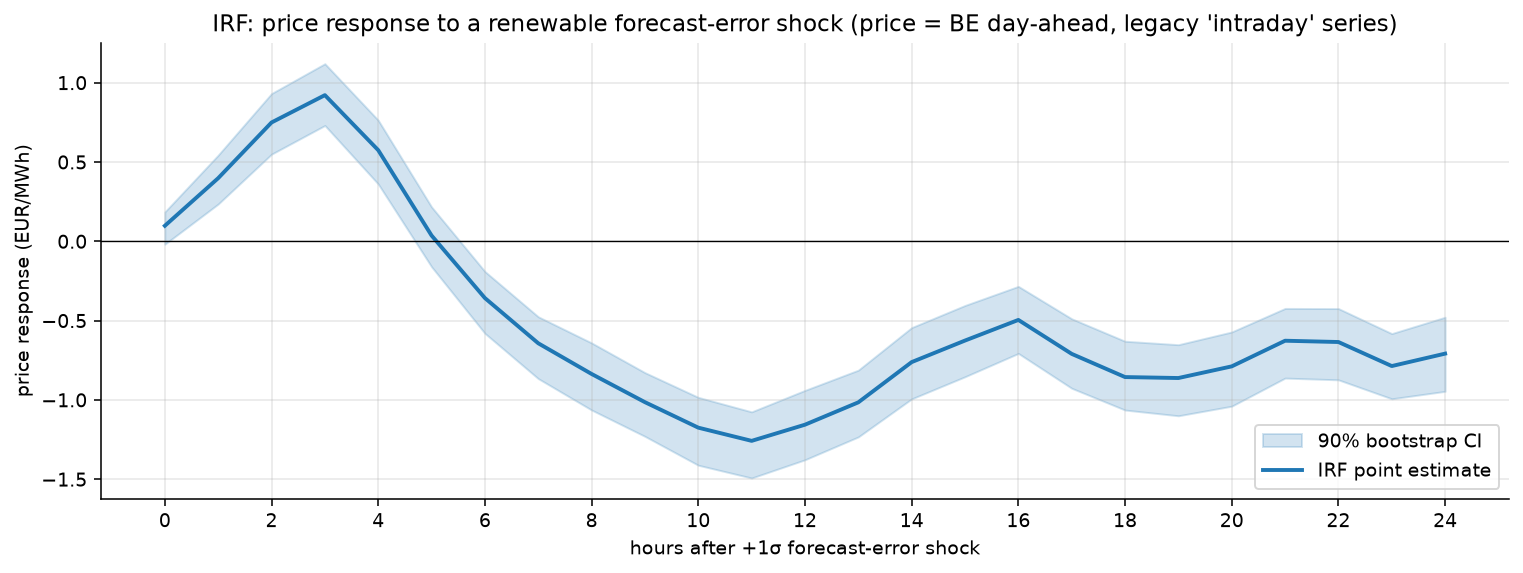

In [7]:
display(Image(str(FIG / 'q1_irf_and_fevd.png')))

In [8]:
df = pd.read_csv(TAB / 'q1_irf_path.csv', index_col=0)
display(df.head(12))

,irf,lower_5,upper_95
horizon_h,,,
0,0.097739,-0.018525,0.185129
1,0.398005,0.234870,0.543218
2,0.749100,0.549210,0.931458
3,0.921434,0.730112,1.119692
4,0.574494,0.361185,0.763401
5,0.036355,-0.160797,0.216526
6,-0.357989,-0.580671,-0.190422
7,-0.643123,-0.865987,-0.475872
8,-0.836623,-1.063891,-0.640807


**Reading the IRF.** Sign and size of the price response to a one-sigma
forecast-error shock. The hypothesised sign is negative: more renewables than
expected means excess supply and bearish pressure. The bands are the 5th and
95th percentiles of the residual bootstrap.


## 4.  Rolling Granger: temporal stability

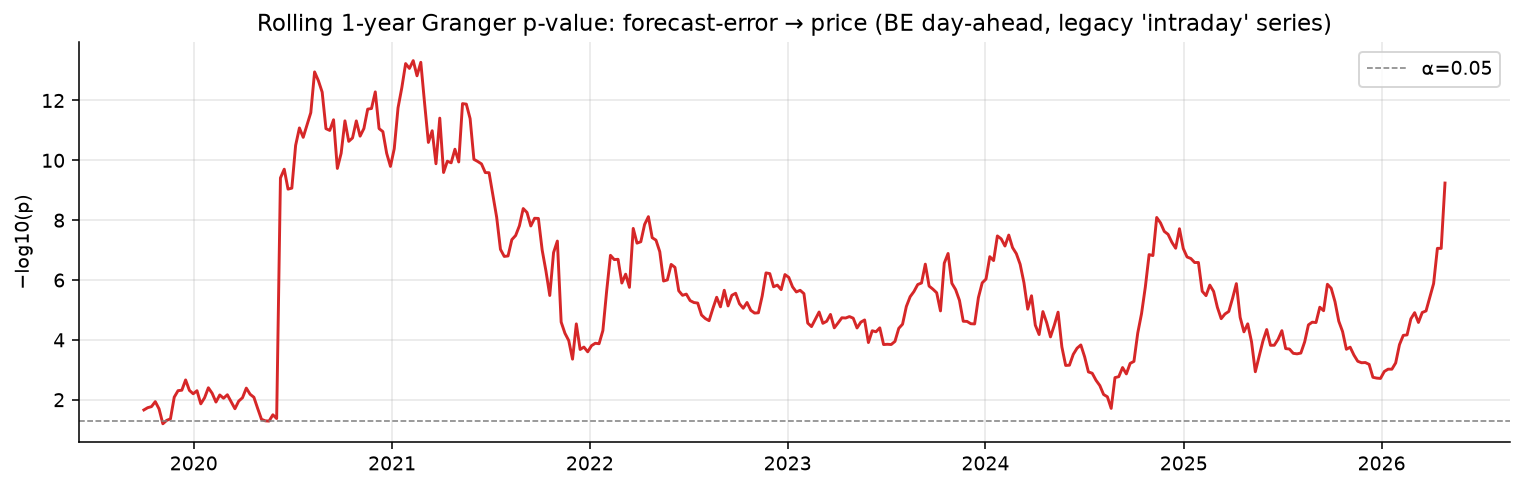

In [9]:
display(Image(str(FIG / 'q1_rolling_granger.png')))

Persistent significance across rolling windows says the relationship is
structural rather than specific to one regime. A clear strengthening trend
would have supported the build-out thesis.


## 5.  Bai-Perron structural breaks

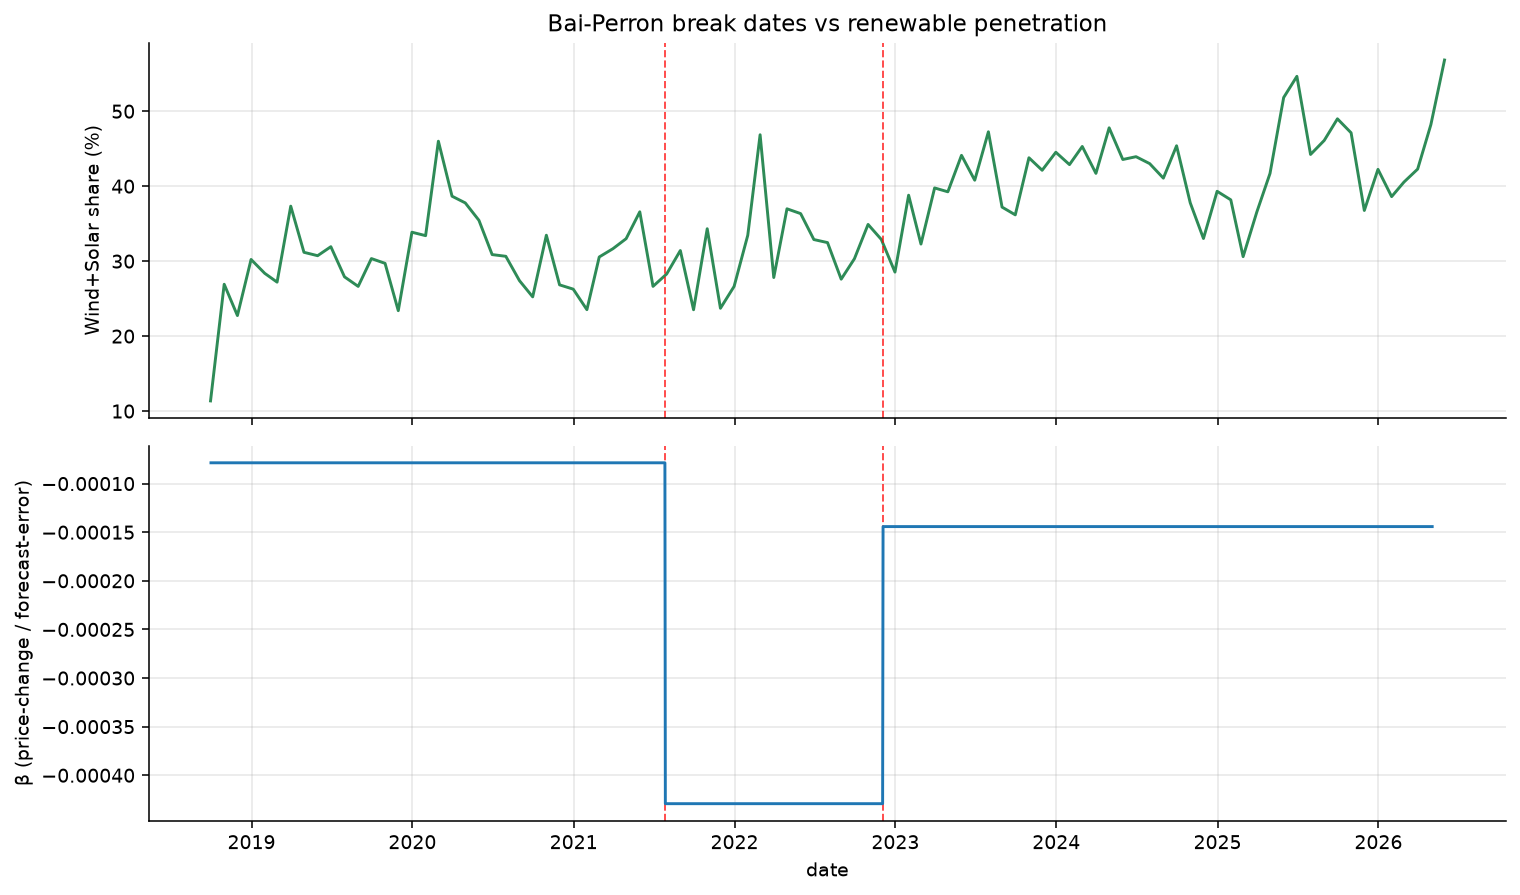

In [10]:
display(Image(str(FIG / 'q1_bai_perron.png')))

In [11]:
df = pd.read_csv(TAB / 'q1_bai_perron_segments.csv', index_col=0)
display(df)

,segment,alpha,beta,r2,n
0,0,0.008660,-0.000079,0.025239,1031
1,1,0.136703,-0.000429,0.044128,494
2,2,-0.007322,-0.000144,0.034766,1247


In [12]:
bp = SUMMARY['q1_bai_perron']
display(Markdown(
    f"""
**Detected breaks ({bp['n_breaks']}):** {', '.join(bp['break_dates']) or 'none'}.

Per-segment slope on `total_error`: {[round(b, 5) for b in bp['segment_betas']]}.

Reading these against the renewable-share panel above: a break that lands on
a major capacity-addition window is the empirical anchor for the project's
narrative. A break that lands on a known macro shock (e.g. early 2022 energy
crisis) is not: that's a price-regime break, not a capacity story.
"""
))


**Detected breaks (2):** 2021-07-27, 2022-12-03.

Per-segment slope on `total_error`: [-8e-05, -0.00043, -0.00014].

Reading these against the renewable-share panel above: a break that lands on
a major capacity-addition window is the empirical anchor for the project's
narrative. A break that lands on a known macro shock (e.g. early 2022 energy
crisis) is not: that's a price-regime break, not a capacity story.


## 6. Conclusions for Q1

The cell below pulls the headline numbers from `results/summary.json` into one
paragraph.


In [13]:
g = SUMMARY['q1_granger']
bp = SUMMARY['q1_bai_perron']
n_yrs = (pd.Timestamp(WINDOW['end']) - pd.Timestamp(WINDOW['start'])).days / 365.25
display(Markdown(
f"""
**Q1, in short.**

1. Over **{n_yrs:.1f} years** of hourly DE/LU data ({g['n_obs']:,} obs after
   stationarity prep), renewable forecast errors Granger-cause the next-day
   Belgian auction price at AIC-selected lag **{g['lag']}h**,
   F = **{g['F_forward']:.2f}**, p = **{g['p_forward']:.2e}**. The reverse
   direction also rejects (F = {g['F_reverse']:.2f}, p = {g['p_reverse']:.2e});
   on a sample this long that is what shared drivers produce, so Granger here is
   necessary but not sufficient.

2. The IRF (table `q1_irf_path`) traces the sign and decay of the response,
   which Granger does not. The variance decomposition bounds how much price
   variance forecast-error innovations explain; that bound is the number to
   quote.

3. Bai-Perron finds **{bp['n_breaks']} break(s)** in the daily coefficient.
   Whether they align with capacity additions or with the gas crisis decides
   the build-out thesis; the figure above overlays both.

Caveats: bidirectional Granger on long samples conflates the mechanism with
common drivers (load forecast error, weather); a VAR with load error as an
exogenous term is the next step. The break test runs on daily means; the hourly
version finds more breaks, mostly short-lived noise.
"""
))



**Q1, in short.**

1. Over **7.6 years** of hourly DE/LU data (66,526 obs after
   stationarity prep), renewable forecast errors Granger-cause the next-day
   Belgian auction price at AIC-selected lag **24h**,
   F = **11.05**, p = **2.07e-42**. The reverse
   direction also rejects (F = 8.31, p = 1.55e-29);
   on a sample this long that is what shared drivers produce, so Granger here is
   necessary but not sufficient.

2. The IRF (table `q1_irf_path`) traces the sign and decay of the response,
   which Granger does not. The variance decomposition bounds how much price
   variance forecast-error innovations explain; that bound is the number to
   quote.

3. Bai-Perron finds **2 break(s)** in the daily coefficient.
   Whether they align with capacity additions or with the gas crisis decides
   the build-out thesis; the figure above overlays both.

Caveats: bidirectional Granger on long samples conflates the mechanism with
common drivers (load forecast error, weather); a VAR with load error as an
exogenous term is the next step. The break test runs on daily means; the hourly
version finds more breaks, mostly short-lived noise.
